# Implementasi Dinov3 - Huge untuk Image Classification

## Team Over/Under 35.5
- Bob Kunanda
- Haegen Quinston
- Nathaniel Jonathan Rusli

### Spesifikasi
- **Model**: facebook/dinov3-vith16plus-pretrain-lvd1689m (Huge)
- **Pendekatan**: EDA + Feature Extraction + custom classification head + Hyperparameter Tuning
- **Framework**: PyTorch dengan library Transformers

## 1. Environment & Dependency Setup

### 1.1 Latar Belakang Pemilihan Tools
Pada tahap ini, disiapkan environment dengan menginstal library yang diperlukan dan mengimpor modul-modul yang akan digunakan. Pemilihan library ini didasarkan pada kebutuhan untuk:

1. **Efisiensi Komputasi**: PyTorch dengan CUDA support untuk akselerasi GPU
2. **State-of-the-art Models**: Transformers library untuk akses model DINOv3
3. **Augmentasi Data**: torchvision untuk preprocessing dan augmentasi gambar
4. **Evaluasi Model**: scikit-learn untuk metrik evaluasi yang komprehensif

### 1.2 Instalasi Library Transformers

Library transformers perlu diupgrade ke versi terbaru untuk memastikan kompatibilitas dengan model DINOv3 yang relatif baru. Versi terbaru juga mengandung optimasi dan perbaikan bug yang penting untuk performa model.

In [1]:
!pip install --upgrade transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 99.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.1/566.1 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 77.2 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 1.0.0rc2
    Uninstalling huggingface-hub-1.0.0rc2:
      Successfully uninstalled huggingface-hub-1.0.0rc2
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.21.2
    Uninstalling tokenizers-0.21.2:
      Successfully uninstalled tokenizers-0.21.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.53.3
    Uninstalling transformers-4.53.3:
      Successfully uninstalled transformers-4.53.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source 

### 1.3 Import Library yang Diperlukan

- **Machine Learning**: PyTorch, scikit-learn, transformers untuk implementasi model dan evaluasi
- **Data Preprocessing**: PIL untuk manipulasi gambar, pandas dan numpy untuk data handling
- **Data Visualization**: matplotlib untuk plotting dan analisis visual
- **Utilities**: os untuk file handling, random untuk kontrol randomness, tqdm untuk progress tracking

Setiap library dipilih berdasarkan standar industri dan kemampuan optimasi yang telah terbukti dalam penelitian deep learning.

In [2]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from transformers import AutoModel
from torch.amp import autocast, GradScaler
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.transforms import v2

from huggingface_hub import login
from kaggle_secrets import UserSecretsClient
import imagehash
from PIL import Image
import itertools

import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
 
print(torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # untuk multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8" 

    def seed_worker(worker_id):
        worker_seed = seed + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)
    return seed_worker

seed = 42
seed_worker = seed_everything(seed)
print(f"Global seed set to {seed}")

2.6.0+cu124
Using device: cuda
Global seed set to 42


### 1.4 Setup Reproduktibilitas

**Pentingnya Reproduktibilitas:**
Dalam penelitian machine learning, reproduktibilitas hasil sangat penting untuk:
1. **Validasi Ilmiah**: Memastikan hasil dapat direplikasi oleh peneliti lain
2. **Debugging**: Memudahkan identifikasi masalah jika terjadi error
3. **Perbandingan Model**: Memberikan baseline yang konsisten untuk eksperimen

**Implementasi Seed Control:**
- Kontrol random seed untuk semua library (numpy, torch, python random)
- Pengaturan deterministic mode untuk CUDA operations
- Environment variables untuk memastikan konsistensi across platforms

## 2. Exploratory Data Analysis

### 2.1 Metodologi Pemahaman Data
Tahap eksplorasi data merupakan fondasi penting dalam setiap proyek machine learning. Pada tahap ini, kami melakukan:

1. **Identifikasi Struktur Data**: Memahami organisasi folder dan naming convention
2. **Analisis Distribusi Kelas**: Mengetahui balance/imbalance dataset
3. **Ekstraksi Metadata**: Mengumpulkan informasi tentang jumlah sampel per kelas

Tahap ini penting agar kami dapat menentukan strategi preprocessing yang tepat, mengidentifikasi potensi bias dan ketidakseimbangan kelas, dan merencanakan strategi augmentasi yang sesuai.

In [3]:
train_dir = "/kaggle/input/logikaui-gacorv1/Train/Train"
class_names = datasets.ImageFolder(root=train_dir).classes
print("Kelas:", class_names)

Kelas: ['balinese', 'batak', 'dayak', 'javanese', 'minangkabau']


#### Visualisasi Distribusi Kelas

In [4]:
class_data = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    num_items = len(os.listdir(class_path))
    class_data.append((class_name, num_items))

df_dist = pd.DataFrame(class_data, columns=['Class', 'Count'])
print("--- Class Distribution ---")
print(df_dist)
print(f"\nTotal training images: {df_dist['Count'].sum()}")

--- Class Distribution ---
         Class  Count
0     balinese    781
1        batak     92
2        dayak     72
3     javanese    249
4  minangkabau    558

Total training images: 1752


#### Bar Chart Distribusi Kelas

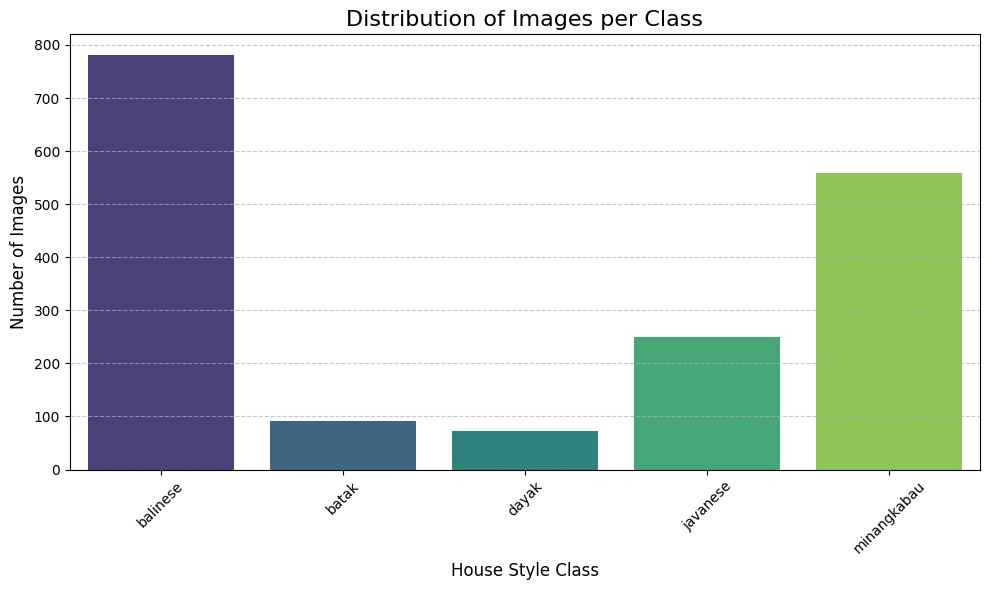

In [5]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Class', y='Count', data=df_dist, palette='viridis')
plt.title('Distribution of Images per Class', fontsize=16)
plt.xlabel('House Style Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 2.2 Perbandingan menggunakan Cosine Similarity

Metode ini dilakukan untuk memastikan kualitas dan integritas dataset sebelum training. Analisis cosine similarity memiliki tujuan strategis penting: 
1. Mendeteksi duplikasi dan near-duplicates yang dapat menyebabkan data leakage antara training dan validation set, menghasilkan evaluasi bias dan overfitting tersembunyi. 
2. Memahami keragaman visual antar kelas rumah adat Indonesia dengan detail halusnya, sehingga dapat mengidentifikasi seberapa distinct setiap kelas dan mendeteksi potensi confounding features.
3. Berfungsi sebagai quality control untuk validasi konsistensi anotasi - gambar sangat mirip dengan label berbeda mengindikasikan kesalahan pelabelan yang harus diperbaiki sebelum training. 
4. Menginformasikan strategi augmentasi optimal; jika similarity antar kelas terlalu tinggi, diperlukan augmentasi yang lebih hati-hati untuk meningkatkan separabilitas tanpa merusak fitur semantik penting.

In [6]:
DATASET_DIR = "/kaggle/input/dsc-logika-ui-2025/Train/Train" 

# Ambil semua path gambar dari semua subfolder
image_paths = []
for root, _, files in os.walk(DATASET_DIR):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_paths.append(os.path.join(root, f))

print(f"Total gambar ditemukan: {len(image_paths)}")

# Hitung perceptual hash untuk tiap gambar
hashes = {}
for path in tqdm(image_paths, desc="Menghitung hash gambar"):
    try:
        with Image.open(path) as img:
            img_hash = imagehash.phash(img)
            hashes[path] = img_hash
    except Exception as e:
        print(f"Gagal membaca {path}: {e}")

# Bandingkan antar gambar untuk cari yang sangat mirip
similar_pairs = []
paths = list(hashes.keys())

for i, j in tqdm(itertools.combinations(range(len(paths)), 2), total=len(paths)*(len(paths)-1)//2):
    path1, path2 = paths[i], paths[j]
    diff = hashes[path1] - hashes[path2]
    if diff <= 5:  # threshold kesamaan (semakin kecil, semakin mirip)
        similar_pairs.append({
            "img1": path1,
            "img2": path2,
            "hash_diff": diff
        })

print(f"\nDitemukan {len(similar_pairs)} pasangan gambar mirip (diff <= 5)")
df = pd.DataFrame(similar_pairs)
print(df.head(10))

Total gambar ditemukan: 0


Menghitung hash gambar: 0it [00:00, ?it/s]
0it [00:00, ?it/s]


Ditemukan 0 pasangan gambar mirip (diff <= 5)
Empty DataFrame
Columns: []
Index: []


## 3. Preprocessing & Data Augmentation

### 3.1 Justifikasi
Dataset berisi manusia dengan pakaian/aksesoris etnik yang bergantung pada detail halus (motif, headpiece), namun foto diambil dalam kondisi tak terkontrol—sudut, jarak, dan crop bervariasi, serta sering ada latar panggung, ornamen, watermark, atau banner yang bisa menjadi “shortcut” non-semantik; selain itu terdapat ketimpangan kelas dengan sebagian kelas beranggotakan sedikit contoh. Karena itu, strategi augmentasi ditujukan untuk membuat model robust terhadap perubahan framing, pose, dan pencahayaan—seperti random crop moderat, flip, rotasi kecil, dan jitter ringan—sembari menjaga agar transformasi tidak merusak atau mengaburkan motif yang menjadi sinyal semantik utama.

### 3.2 Implementasi Transformasi Gambar

**Rasionale Pemilihan Ukuran Gambar (320x320):**
- **Trade-off Resolusi vs Komputasi**: Ukuran yang cukup besar untuk detail namun tetap efisien secara komputasi
- **Kompatibilitas Model**: Sesuai dengan arsitektur DINOv3 yang dapat handle berbagai resolusi
- **Memory Efficiency**: Optimal untuk batch size yang diinginkan dengan keterbatasan GPU memory

**Pipeline Training:**
1. **RandomResizedCrop**: Simulasi variasi jarak dan framing objek
2. **RandomHorizontalFlip**: Augmentasi yang safe untuk kebanyakan domain gambar  
3. **RandomRotation (15°)**: Rotasi kecil untuk menghindari distorsi berlebihan pada motif
4. **ColorJitter**: Variasi brightness dan contrast untuk robustness pencahayaan
5. **Normalisasi ImageNet**: Standar untuk transfer learning dari pre-trained models

**Pipeline Validation:**
- **Simple Resize**: Mempertahankan aspek ratio gambar asli
- **Center Crop Implisit**: Melalui resize yang konsisten
- **Normalisasi Konsisten**: Sama dengan training untuk kompatibilitas model

In [7]:
IMG_SIZE = (320, 320)

#### Training

In [8]:
train_transform = v2.Compose([
    v2.ToImage(),
    v2.RandomResizedCrop(size=IMG_SIZE, scale=(0.8, 1.0), antialias=True),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(degrees=15),                 # kecil saja biar tidak merusak motif
    v2.ColorJitter(brightness=0.2, contrast=0.2),  # photometric ringan
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=(0.485, 0.456, 0.406),
                 std=(0.229, 0.224, 0.225)),
])

#### Validation

In [9]:
val_transform = v2.Compose([
    v2.ToImage(),                                   # ke Tensor uint8 [H,W,C]
    v2.Resize(IMG_SIZE, antialias=True),           
    v2.ToDtype(torch.float32, scale=True),         # skala ke [0,1]
    v2.Normalize(mean=(0.485, 0.456, 0.406),
                 std=(0.229, 0.224, 0.225)),
])

## 4. Autentikasi Hugging Face

**Implementasi Kaggle Secrets:**
- Memanfaatkan UserSecretsClient untuk akses token yang aman
- Token disimpan terenkripsi di environment Kaggle

Model DINOv3 memerlukan autentikasi karena merupakan model yang relatif baru dan mungkin memiliki batasan akses tertentu pada Hugging Face Hub.

In [ ]:
# Authentication removed for security reasons
# Use your own Hugging Face token by setting the environment variable or using huggingface_hub login
print("Please ensure you're logged in to Hugging Face before running the model loading code below.")

Successfully logged in to Hugging Face automatically!


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = AutoModel.from_pretrained("facebook/dinov3-vith16plus-pretrain-lvd1689m")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Using device: cuda


config.json:   0%|          | 0.00/744 [00:00<?, ?B/s]

2025-11-15 09:16:22.183885: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763198182.594448      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763198182.701899      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


model.safetensors:   0%|          | 0.00/3.36G [00:00<?, ?B/s]

## 5. Model Architecture & Setup

### 5.1 Pemilihan Model DINOv3 Huge
**Keunggulan DINOv3:**
1. **Self-Supervised Learning**: Dilatih tanpa label, menghasilkan representasi yang general
2. **Scale Advantage**: Model Huge memiliki kapasitas representasi yang sangat besar
3. **Transfer Learning Capability**: Excellent feature extractor untuk downstream tasks
4. **State-of-the-art Performance**: Mengungguli many supervised pre-trained models

**Spesifikasi Teknis:**
- **Arsitektur**: Vision Transformer dengan patch size 16
- **Hidden Size**: 1024 (huge variant)
- **Parameters**: ~800M parameter untuk feature extraction
- **Training Data**: LVD-142M (Large-scale Vision Dataset)

### 5.2 Desain Custom DINOv3 Classifier

**Arsitektur Hybrid:**
Model ini menggabungkan:
1. **Frozen DINOv3 Backbone**: Pre-trained feature extractor (parameter dibekukan)
2. **Trainable Classification Head**: Linear layer custom untuk kelas spesifik

**Keuntungan Pendekatan Feature Extraction:**
- **Efisiensi Komputasi**: Hanya melatih ~0.1% dari total parameter
- **Leverage Pre-trained Knowledge**: Memanfaatkan representasi yang sudah powerful
- **Reduced Overfitting**: Backbone yang stabil mengurangi risiko overfitting
- **Fast Training**: Waktu training yang jauh lebih cepat dibanding full fine-tuning
- **Lower Resource Requirements**: Memory dan compute yang lebih efisien

**Implementasi Technical Details:**
- **Parameter Freezing**: `requires_grad = False` untuk semua parameter backbone
- **Feature Dimension**: Mengekstrak hidden_size dari konfigurasi model
- **Output Mapping**: Linear transformation dari feature space ke class probabilities
- **Forward Pass**: Feature extraction → pooling → classification

In [12]:
class DinoV3Classifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Load the base DINOv3 model
        self.dinov3 = AutoModel.from_pretrained("facebook/dinov3-vith16plus-pretrain-lvd1689m")

        # Freezing
        for param in self.dinov3.parameters():
            param.requires_grad = False

        # Feature dimension
        num_features = self.dinov3.config.hidden_size

        # Create a new transferable classification head
        self.classifier = nn.Linear(num_features, num_classes)

    def forward(self, pixel_values):
        # Get the feature vector from the base model
        outputs = self.dinov3(pixel_values=pixel_values)
        feature_vector = outputs.pooler_output
        
        logits = self.classifier(feature_vector)
        return logits

model = DinoV3Classifier(num_classes=len(class_names))
model = model.to(device)

optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print("DINOv3 model with custom classifier created successfully!")

DINOv3 model with custom classifier created successfully!


## 6. Data Splitting Strategy

### 6.1 Strategi Train/Validation Split
**Metodologi Stratified Splitting:**
- **Rasio 80:20**: Proporsi standar yang memberikan data training yang cukup sambil mempertahankan validation set yang representatif
- **Stratified Sampling**: Memastikan distribusi kelas yang seimbang di kedua split
- **Random State Fixed**: Seed 42 untuk reproduktibilitas hasil

**Justifikasi Strategi:**
1. **Representativity**: Setiap split memiliki proporsi kelas yang sama dengan dataset asli
2. **Bias Prevention**: Mencegah training set yang tidak representatif
3. **Evaluation Reliability**: Validation set yang balanced memberikan evaluasi yang fair

### 6.2 Konfigurasi DataLoader

**Optimasi Parameter DataLoader:**
- **Batch Size 32**: Trade-off optimal antara memory usage dan gradient quality
  - Cukup besar untuk stable gradient estimation
  - Tidak terlalu besar untuk menghindari memory overflow
  - Optimal untuk mixed precision training
  
- **Num Workers 4**: Parallel data loading untuk efisiensi I/O
  - Mengurangi bottleneck data loading
  - Optimal untuk sistem (4 CPU cores)

- **Pin Memory True**: Optimasi untuk GPU training
  - Faster data transfer dari CPU ke GPU memory
  - Penting untuk training dengan dataset besar
  - Mengurangi latency transfer data

**Data Pipeline Efficiency:**
- **Non-blocking Transfer**: Overlap data loading dengan computation
- **Prefetching**: Data untuk batch berikutnya dimuat sementara batch saat ini diproses
- **Memory Management**: Efficient memory usage dengan pin_memory optimization

In [13]:
dataset = datasets.ImageFolder(root=train_dir)
targets = [sample[1] for sample in dataset.samples]

train_idx, val_idx = train_test_split(
    range(len(targets)),
    test_size=0.2,
    stratify=targets,
    random_state=42
)

train_dataset = Subset(dataset, train_idx)
val_dataset   = Subset(dataset, val_idx)

train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform   = val_transform

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Train samples: 1401
Validation samples: 351


## 7. Model Training

### Advanced Training Loop Implementation

**Fitur-Fitur Advanced yang Diimplementasi:**

**1. Mixed Precision Training:**
- **Automatic Mixed Precision (AMP)**: Menggunakan float16 untuk forward pass, float32 untuk backward
- **Gradient Scaling**: Mencegah gradient underflow dalam precision rendah
- **Performance Benefit**: 1.5-2x speedup training dengan minimal accuracy loss
- **Memory Efficiency**: Pengurangan memory usage hingga 50%

**2. Optimasi AdamW:**
- **Weight Decay Decoupling**: Separated weight decay dari gradient-based updates
- **Better Generalization**: Terbukti lebih baik daripada Adam standard untuk vision tasks
- **Learning Rate 1e-3**: Optimal untuk fine-tuning classification heads
- **Weight Decay 1e-4**: Regularization yang cukup tanpa over-penalization

**3. Comprehensive Metrics Tracking:**
- **F1 Score Macro**: Metrik yang fair untuk multi-class classification
- **Per-epoch Monitoring**: Training dan validation metrics untuk setiap epoch
- **Best Model Checkpointing**: Save model berdasarkan validation F1 tertinggi
- **Progress Visualization**: Real-time monitoring dengan tqdm

**4. Training Strategy:**
- **Feature Extraction Approach**: Hanya train classification head
- **Gradient Accumulation**: Set_to_none=True untuk memory efficiency
- **Validation Loop**: Comprehensive evaluation setiap epoch
- **Early Stopping Indicator**: Monitor validation F1 untuk overfitting detection

In [14]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

trainable_params = [p for p in model.parameters() if p.requires_grad]
if len(trainable_params) == 0:
    raise RuntimeError("No trainable parameters found after head configuration.")

optimizer = torch.optim.AdamW(trainable_params, lr=1e-3, weight_decay=1e-4)

criterion = nn.CrossEntropyLoss().to(device)
scaler = GradScaler('cuda', enabled=use_cuda)

train_size = len(train_loader.dataset)
val_size   = len(val_loader.dataset)

num_epochs = 10
best_val_f1 = 0.0
best_model_path = "best_model.pth"

print(f"Training on: {device}")
print(f"Trainable params: {sum(p.numel() for p in trainable_params):,}")

for epoch in range(num_epochs):
    model.train()
    running_loss, running_corrects = 0.0, 0
    all_preds, all_labels = [], []

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(True):
            with autocast('cuda', enabled=use_cuda):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += (preds == labels).sum().item()
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / train_size
    epoch_acc  = running_corrects / train_size
    epoch_f1   = f1_score(all_labels, all_preds, average="macro")

    # Validasi
    model.eval()
    val_loss, val_corrects = 0.0, 0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc="Validation"):
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with autocast('cuda', enabled=use_cuda):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            val_loss += loss.item() * inputs.size(0)
            val_corrects += (preds == labels).sum().item()
            val_preds.extend(preds.detach().cpu().numpy())
            val_labels.extend(labels.detach().cpu().numpy())

    val_epoch_loss = val_loss / val_size
    val_epoch_acc  = val_corrects / val_size
    val_epoch_f1   = f1_score(val_labels, val_preds, average="macro")

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} F1: {epoch_f1:.4f}")
    print(f"  Val   Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.4f} F1: {val_epoch_f1:.4f}")

    if val_epoch_f1 > best_val_f1:
        best_val_f1 = val_epoch_f1
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1': val_epoch_f1,
        }, best_model_path)
        print(f" Model saved (best val F1: {best_val_f1:.4f})")

print(f"Training complete! Best validation F1: {best_val_f1:.4f}")

Training on: cuda
Trainable params: 6,405


Validation: 100%|██████████| 11/11 [00:42<00:00,  3.89s/it]



Epoch 1/10
  Train Loss: 0.6925 Acc: 0.8001 F1: 0.5557
  Val   Loss: 0.3961 Acc: 0.8775 F1: 0.7509
 Model saved (best val F1: 0.7509)


Validation: 100%|██████████| 11/11 [00:42<00:00,  3.83s/it]



Epoch 2/10
  Train Loss: 0.3568 Acc: 0.9015 F1: 0.8017
  Val   Loss: 0.3059 Acc: 0.9088 F1: 0.7791
 Model saved (best val F1: 0.7791)


...


Epoch 8/10
  Train Loss: 0.1535 Acc: 0.9679 F1: 0.9493
  Val   Loss: 0.2181 Acc: 0.9573 F1: 0.9305


Validation: 100%|██████████| 11/11 [00:42<00:00,  3.82s/it]



Epoch 9/10
  Train Loss: 0.1391 Acc: 0.9764 F1: 0.9633
  Val   Loss: 0.2174 Acc: 0.9544 F1: 0.9280


Validation: 100%|██████████| 11/11 [00:42<00:00,  3.84s/it]



Epoch 10/10
  Train Loss: 0.1286 Acc: 0.9743 F1: 0.9595
  Val   Loss: 0.2129 Acc: 0.9630 F1: 0.9510
 Model saved (best val F1: 0.9510)
Training complete! Best validation F1: 0.9510


## 8. Model Inference, Prediction & Submission

### Pipeline Prediksi Test Set

**Prosedur Loading Model Terbaik:**
1. **Checkpoint Recovery**: Memuat state model dengan validation F1 tertinggi
2. **State Consistency**: Memastikan arsitektur model identik dengan training
3. **Evaluation Mode**: Mengaktifkan mode evaluasi (dropout off, batch norm frozen)

**Optimasi Proses Inferensi:**
- **Batch Processing**: Memproses gambar satu per satu untuk error handling yang baik
- **Error Handling**: Skip file yang corrupt atau format tidak didukung
- **Mixed Precision Consistency**: Menggunakan autocast untuk konsistensi dengan training
- **Non-blocking Transfer**: Optimasi GPU utilization
- **Memory Management**: Context manager untuk menghindari memory leak

**Format Output yang Terstruktur:**
- **Image ID Extraction**: Mengambil nama file tanpa ekstensi
- **Class Name Mapping**: Konversi dari indeks numerik ke nama kelas
- **Sorted Output**: Mengurutkan berdasarkan ID untuk consistency submission
- **Error Logging**: Mencatat gambar yang gagal diproses untuk debugging

**Validasi Prediksi:**
- **Sanity Check**: Memverifikasi jumlah prediksi sesuai dengan jumlah test images
- **Format Verification**: Memastikan format output sesuai dengan requirement kompetisi

In [15]:
checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

test_dir = "/kaggle/input/logikaui-gacorv1/Test/Test"
test_images = sorted(os.listdir(test_dir))  # urutkan biar sesuai

predictions = []
ids = []

inference_transform = val_transform 

with torch.no_grad():
    for img_name in tqdm(test_images, desc="Predicting Test"):
        if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue
            
        img_path = os.path.join(test_dir, img_name)
        
        try:
            img = datasets.folder.default_loader(img_path) 
            img = inference_transform(img).unsqueeze(0).to(device, non_blocking=True)
            
            with autocast('cuda'):
                outputs = model(img)
            
            _, pred = torch.max(outputs, 1)
            pred_class = class_names[pred.item()]
            
            # id = nama file tanpa .jpg
            img_id = os.path.splitext(img_name)[0]
            ids.append(img_id)
            predictions.append(pred_class)
            
        except Exception as e:
            print(f"Error processing {img_name}: {e}")
            continue

print(f"\n✅ Prediction complete! {len(predictions)} images processed")

Predicting Test: 100%|██████████| 444/444 [02:45<00:00,  2.68it/s]


✅ Prediction complete! 444 images processed


### Export File Submission

**Pembuatan File Submission CSV:**
- **Struktur Data**: DataFrame dengan kolom 'id' dan 'style' sesuai requirement
- **Sorting**: Mengurutkan berdasarkan ID untuk konsistensi evaluasi
- **Format Validation**: Memastikan tidak ada missing values atau format error
- **File Naming**: Penamaan yang descriptive untuk tracking eksperimen (DinoV3H_submission4.csv)

In [16]:
df = pd.DataFrame({"id": ids, "style": predictions})
df = df.sort_values(by="id")  # pastikan urut
df.to_csv("DinoV3H_submission4.csv", index=False)

print("Hasil prediksi disimpan ke submission.csv")

Hasil prediksi disimpan ke submission.csv


# 9. Analisis & Evaluasi Model

### 9.1 Metodologi Evaluasi Komprehensif
Evaluasi model merupakan tahap kritis untuk memahami performa dan limitasi model yang telah dikembangkan. Analisis yang komprehensif mencakup berbagai metrik dan visualisasi untuk memberikan insight yang mendalam tentang behavior model.

### 9.2 Analisis Performa Validation Set

**Komponen Analisis yang Dilakukan:**

**1. Classification Report:**
- **Precision per Kelas**: Seberapa akurat prediksi positif untuk setiap kelas
- **Recall per Kelas**: Seberapa lengkap model mendeteksi sampel dari setiap kelas  
- **F1-Score per Kelas**: Harmonic mean dari precision dan recall
- **Support**: Jumlah sampel aktual per kelas dalam validation set

**2. Confusion Matrix Normalisasi:**
- **Visualisasi Error Pattern**: Identifikasi kelas mana yang sering dikacaukan
- **Percentage-based**: Normalisasi untuk memudahkan interpretasi across classes
- **Diagonal Dominance**: Indikator performa yang baik jika nilai diagonal tinggi
- **Off-diagonal Analysis**: Memahami systematic errors dan class similarities

**3. Metrik Kunci untuk Interpretasi:**
- **Macro-averaged F1**: Performa overall tanpa bias terhadap kelas mayoritas
- **Weighted-averaged Metrics**: Memperhitungkan class distribution
- **Per-class Performance**: Identifikasi kelas yang challenging vs easy
- **Error Analysis**: Understanding systematic biases dan model limitations

**4. Insight yang Diperoleh:**
- **Strong Performing Classes**: Kelas dengan karakteristik visual yang distinct
- **Challenging Classes**: Kelas dengan overlap visual atau ambiguity
- **Model Bias**: Apakah model bias terhadap kelas tertentu
- **Improvement Opportunities**: Area untuk enhancement di iterasi berikutnya

              precision    recall  f1-score   support

    balinese       0.99      0.96      0.97       157
       batak       1.00      0.89      0.94        18
       dayak       0.93      0.93      0.93        14
    javanese       0.94      0.96      0.95        50
 minangkabau       0.94      0.98      0.96       112

    accuracy                           0.96       351
   macro avg       0.96      0.94      0.95       351
weighted avg       0.96      0.96      0.96       351



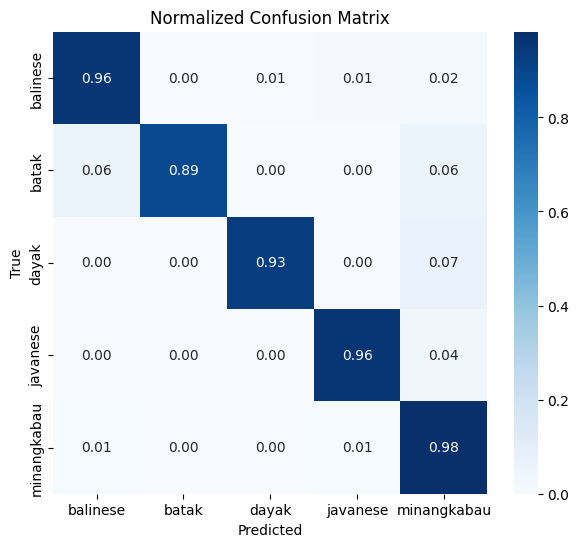

In [17]:
model.eval()
preds, labels = [], []
img_ids = []  # opsional jika val_set punya id

with torch.no_grad():
    for inputs, targets in tqdm(val_loader, desc="Collecting Validation Predictions"):
        inputs, targets = inputs.to(device), targets.to(device)
        with autocast(device_type='cuda', enabled=(device.type == 'cuda')):
            outputs = model(inputs)
        pred = outputs.argmax(1)
        preds.extend(pred.cpu().numpy())
        labels.extend(targets.cpu().numpy())

# simpan ke DataFrame
df_valpred = pd.DataFrame({
    'true_label': labels,
    'pred_label': preds
})

df_valpred['correct'] = (df_valpred['true_label'] == df_valpred['pred_label'])
df_valpred.head()

df_valpred['true_class'] = df_valpred['true_label'].apply(lambda i: class_names[i])
df_valpred['pred_class'] = df_valpred['pred_label'].apply(lambda i: class_names[i])

print(classification_report(df_valpred['true_label'], df_valpred['pred_label'], target_names=class_names))

cm = confusion_matrix(df_valpred['true_label'], df_valpred['pred_label'], normalize='true')
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.show()

Device: cuda:0 | Patch size: 16 | IMG_SIZE: (320, 320)
Using image: /kaggle/input/logikaui-gacorv1/Train/Train/minangkabau/minangkabau_train_000495.jpg


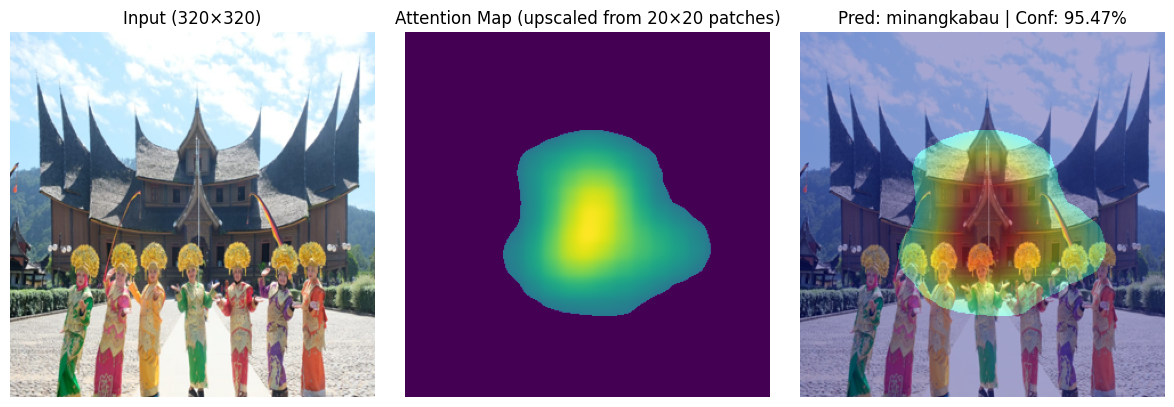

In [18]:
# ============================================================
# Simple Attention CAM untuk DINOv3 (tanpa grad, inspired by snippet #2)
# ============================================================
import math
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

device = next(model.parameters()).device
model.to(device)
model.eval()

patch_size = getattr(model.dinov3.config, "patch_size", 16)
N_SPECIAL_TOKENS = 5  # 1 CLS + 4 register tokens di DINOv3

print("Device:", device, "| Patch size:", patch_size, "| IMG_SIZE:", IMG_SIZE)

# Pastikan backbone bisa mengeluarkan attentions
if hasattr(model.dinov3, "set_attn_implementation"):
    model.dinov3.set_attn_implementation("eager")


# ------------------------------------------------------------
# 1. Kelas visualisasi attention DINOv3
# ------------------------------------------------------------
class DinoV3AttentionVisualization:
    """
    Visualize attention map dari DINOv3:
    - pakai attention dari layer encoder terakhir
    - average across heads
    - ambil attention CLS → patch tokens
    - reshape ke grid patch dan di-normalisasi
    """
    def __init__(self, model):
        self.model = model

    def generate_cam_from_tensor(self, input_tensor):
        """
        input_tensor: [1,3,H,W] (sudah di-preprocess dengan val_transform, di device yang sama dengan model)
        return:
          cam_spatial: np.array [H_p, W_p] di [0,1]
          (H_p, W_p): ukuran grid patch
        """
        self.model.eval()

        with torch.no_grad():
            outputs = self.model.dinov3(pixel_values=input_tensor, output_attentions=True)

        attentions = outputs.attentions  # tuple[L] of [B, heads, T, T]
        if attentions is None or len(attentions) == 0:
            print("⚠️ Warning: DINOv3 tidak mengeluarkan attention maps.")
            return None, None

        # Ambil attention dari layer terakhir
        last_attention = attentions[-1]          # [B, heads, T, T]
        attn = last_attention[0]                # sample pertama: [heads, T, T]

        # Average across heads
        attn_avg = attn.mean(dim=0)            # [T, T]

        # CLS token attention ke semua token
        # DINOv3: idx 0 = CLS, 1..4 = register, 5.. = patch
        cls_to_all = attn_avg[0]               # [T]

        # Ambil hanya patch tokens
        patch_attn = cls_to_all[N_SPECIAL_TOKENS:]  # [N_patches]

        # Hitung grid size patch dari IMG_SIZE & patch_size
        if isinstance(IMG_SIZE, int):
            H_img = W_img = IMG_SIZE
        else:
            H_img, W_img = IMG_SIZE

        H_p = H_img // patch_size
        W_p = W_img // patch_size
        num_patches_expected = H_p * W_p

        # Safety: potong/pad kalau seq_len patch != expected
        patch_attn = patch_attn[:num_patches_expected]
        if patch_attn.numel() < num_patches_expected:
            pad = num_patches_expected - patch_attn.numel()
            patch_attn = torch.cat([patch_attn, torch.zeros(pad, device=patch_attn.device)], dim=0)

        # Normalisasi ke [0,1]
        min_val = patch_attn.min()
        max_val = patch_attn.max()
        if (max_val - min_val) > 1e-8:
            patch_attn = (patch_attn - min_val) / (max_val - min_val + 1e-8)
        else:
            print(f"⚠️ Attention variance sangat kecil ({(max_val - min_val).item():.2e})")
            patch_attn = torch.zeros_like(patch_attn)

        cam_spatial = patch_attn.view(H_p, W_p).detach().cpu().numpy()  # [H_p, W_p]
        return cam_spatial, (H_p, W_p)


# Inisialisasi sekali
attn_viz = DinoV3AttentionVisualization(model)


# ------------------------------------------------------------
# 2. Overlay CAM ke gambar 320×320
# ------------------------------------------------------------
def overlay_attention_on_image(pil_img, cam_spatial, alpha=0.45,
                               blur_kernel=7, cutoff=0.4, gamma=0.8):
    """
    pil_img      : PIL.Image
    cam_spatial  : [H_p, W_p] di [0,1] (attention grid)
    alpha        : seberapa kuat heatmap vs image
    blur_kernel  : ukuran kernel Gaussian blur (ganjil: 3,5,7,...)
    cutoff       : nilai CAM di bawah ini dianggap 0 (supaya tidak bintik-bintik)
    gamma        : penguatan non-linear (CAM ** gamma)
    """
    # Paksa ukuran visual = IMG_SIZE (misal 320×320)
    if isinstance(IMG_SIZE, int):
        W_img = H_img = IMG_SIZE
    else:
        H_img, W_img = IMG_SIZE

    pil_img = pil_img.resize((W_img, H_img))
    img_np = np.array(pil_img).astype(np.float32) / 255.0  # [H,W,3]

    cam = cam_spatial.astype(np.float32)

    # 1) Smooth di level patch (biar nggak kotak banget)
    if blur_kernel is not None and blur_kernel > 1:
        k = blur_kernel if blur_kernel % 2 == 1 else blur_kernel + 1
        cam = cv2.GaussianBlur(cam, (k, k), 0)

    # 2) Upsample ke ukuran image
    cam = cv2.resize(cam, (W_img, H_img), interpolation=cv2.INTER_CUBIC)

    # 3) Normalisasi + non-linearity (gamma) supaya area penting menonjol, noise hilang
    cam = cam - cam.min()
    if cam.max() > 0:
        cam = cam / (cam.max() + 1e-8)
    cam = np.power(cam, gamma)

    # 4) Cutoff: nilai kecil → 0 (biar nggak ada “baret-baret” tipis)
    cam[cam < cutoff] = 0.0

    # 5) Colormap JET
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

    # 6) Blend heatmap dengan image
    overlay = (1 - alpha) * img_np + alpha * heatmap
    overlay = overlay / overlay.max()

    return img_np, cam, overlay



# ------------------------------------------------------------
# 3. Helper: run attention CAM untuk 1 gambar
# ------------------------------------------------------------
def run_dinov3_attention_cam(img_path):
    pil_img = Image.open(img_path).convert("RGB")

    # Preprocess untuk model
    input_tensor = val_transform(pil_img).unsqueeze(0).to(device)  # [1,3,H,W]

    # Generate CAM (tidak butuh class_idx di sini, kita pakai attention murni)
    cam_spatial, (H_p, W_p) = attn_viz.generate_cam_from_tensor(input_tensor)
    if cam_spatial is None:
        return

    # Prediksi untuk title
    with torch.no_grad():
        out = model(input_tensor)
        if hasattr(out, "logits"):
            logits = out.logits
        else:
            logits = out
        probs = torch.softmax(logits, dim=1)[0]
        pred_idx = int(probs.argmax().item())
        pred_conf = float(probs[pred_idx].item())

    img_np, cam_resized, overlay = overlay_attention_on_image(pil_img, cam_spatial, alpha=0.35)

    plt.figure(figsize=(12, 4))

    # Original (320×320)
    plt.subplot(1, 3, 1)
    plt.imshow(img_np)
    plt.title("Input (320×320)")
    plt.axis("off")

    # CAM grid upscaled
    plt.subplot(1, 3, 2)
    plt.imshow(cam_resized, cmap="viridis")
    plt.title(f"Attention Map (upscaled from {H_p}×{W_p} patches)")
    plt.axis("off")

    # Overlay
    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    title = f"Pred: {class_names[pred_idx]} | Conf: {pred_conf*100:.2f}%"
    plt.title(title)
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 4. Coba untuk satu sample
# ------------------------------------------------------------
#single_image_path = "/kaggle/input/logikaui-gacorv1/Train/Train/minangkabau/minangkabau_train_000167.jpg"
#single_image_path = "/kaggle/input/logikaui-gacorv1/Train/Train/balinese/balinese_train_000505.jpg"
#single_image_path = "/kaggle/input/logikaui-gacorv1/Train/Train/dayak/dayak_train_000067.jpg"
#single_image_path = "/kaggle/input/logikaui-gacorv1/Train/Train/balinese/balinese_train_000429.jpg"
#single_image_path = "/kaggle/input/logikaui-gacorv1/Train/Train/javanese/javanese_train_000175.jpg"

single_image_path = "/kaggle/input/logikaui-gacorv1/Train/Train/minangkabau/minangkabau_train_000495.jpg"
#single_image_path = "/kaggle/input/logikaui-gacorv1/Train/Train/javanese/javanese_train_000240.jpg"
#single_image_path = "/kaggle/input/logikaui-gacorv1/Train/Train/batak/batak_train_000094.jpg"
#single_image_path = "/kaggle/input/logikaui-gacorv1/Train/Train/dayak/dayak_train_000042.jpg"
print("Using image:", single_image_path)
run_dinov3_attention_cam(single_image_path)


In [19]:

#del model
gc.collect()
torch.cuda.empty_cache()

# device = torch.device("cuda")

# model = DinoV3Classifier(num_classes=num_classes)
# ckpt = torch.load(
#     "/kaggle/working/best_model.pth",
#     map_location="cuda",
#     weights_only=False,
# )
# model.load_state_dict(ckpt["model_state_dict"])
# model.to(device)
# model.eval()

NameError: name 'gc' is not defined

In [ ]:
# ============================================================
# Attention-based CAM untuk DINOv3 (tanpa gradient)
# ============================================================
import math
import torch
import torch.nn.functional as F
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

# ----------------------------
# Konfigurasi dasar
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Jumlah token spesial DINOv3 (1 CLS + 4 register tokens)
N_SPECIAL_TOKENS = 5

# Jika belum ada di notebook, set IMG_SIZE di sini
try:
    IMG_SIZE
except NameError:
    IMG_SIZE = (320, 320)

# Pastikan model sudah ke device dan eval
model.to(device)
model.eval()


# ----------------------------
# Helper: normalisasi CAM ke [0, 1]
# ----------------------------
def normalize_cam(cam: np.ndarray) -> np.ndarray:
    cam = cam - cam.min()
    max_val = cam.max()
    if max_val > 0:
        cam = cam / max_val
    return cam


# ----------------------------
# Helper: preprocessing image
# - Mendukung val_transform Albumentations (dict) maupun torchvision (tensor langsung)
# ----------------------------
def preprocess_image(img_input, val_transform, img_size=(320, 320), device=device):
    """
    img_input: path string ke file atau PIL.Image
    return: img_pil (PIL), img_tensor (1,3,H,W) di device
    """
    if isinstance(img_input, str):
        img_pil = Image.open(img_input).convert("RGB")
    else:
        # diasumsikan sudah PIL.Image.Image
        img_pil = img_input.convert("RGB")

    # Resize eksplisit ke IMG_SIZE agar konsisten dengan training/val
    if img_pil.size != img_size:
        img_pil = img_pil.resize(img_size, resample=Image.BICUBIC)

    transformed = val_transform(img_pil)

    # Handle dua tipe umum: Albumentations (dict) atau torchvision (tensor)
    if isinstance(transformed, dict) and "image" in transformed:
        img_tensor = transformed["image"]
    else:
        img_tensor = transformed

    # Pastikan bentuknya (C,H,W)
    if img_tensor.dim() == 3:
        img_tensor = img_tensor.unsqueeze(0)  # (1,C,H,W)
    elif img_tensor.dim() == 4:
        # sudah batch, tapi kita ambil hanya pertama
        img_tensor = img_tensor[:1]
    else:
        raise ValueError(f"Unexpected tensor shape from val_transform: {img_tensor.shape}")

    img_tensor = img_tensor.to(device)
    return img_pil, img_tensor


# ----------------------------
# Core: generate attention-based CAM dari DINOv3ViTModel
# ----------------------------
def get_dinov3_attention_cam(
    img_input,
    model,
    val_transform,
    n_special_tokens: int = N_SPECIAL_TOKENS,
    img_size=(320, 320),
    device=device,
    blur_ksize: int = 11,
    blur_sigma: float = 10.0,
    thr_quantile: float = 0.6,
    gamma: float = 0.8,
    alpha: float = 0.4,
):
    """
    Menghasilkan attention-based CAM untuk DINOv3 backbone (tanpa gradient).

    Output:
        cam_grid_np: CAM di level patch (GxG) [0,1]
        cam_final: CAM upsample ke img_size [0,1] (sudah blur+threshold+gamma)
        heatmap_color: heatmap warna (RGB, HxWx3, uint8)
        overlay: overlay heatmap di atas image (RGB, HxWx3, uint8)
        img_pil: gambar input (PIL.Image) setelah resize ke img_size
    """
    # 1. Preprocess image
    img_pil, img_tensor = preprocess_image(img_input, val_transform, img_size, device)

    # 2. Forward backbone DINOv3 dengan output_attentions=True
    with torch.no_grad():
        outputs = model.dinov3(
            pixel_values=img_tensor,
            output_attentions=True,
        )
        attentions = outputs.attentions

    # 3. Ambil attention dari layer terakhir: shape [B, heads, T, T]
    last_attn = attentions[-1]  # [1, num_heads, num_tokens, num_tokens]
    b, num_heads, num_tokens, _ = last_attn.shape
    assert b == 1, "Kode ini mengasumsikan batch size = 1 saat visualisasi."

    # 4. Rata-rata head → [B, T, T]
    attn_heads_fused = last_attn.mean(dim=1)  # [1, T, T]

    # 5. Ambil attention dari CLS ke semua token: [T]
    cls_attn = attn_heads_fused[0, 0]  # baris CLS

    # 6. Skip token spesial (CLS + 4 register) → hanya patch tokens
    patch_attn = cls_attn[n_special_tokens:]  # [num_patches]

    # 7. Hitung grid size patch secara otomatis
    num_patches = patch_attn.shape[0]
    grid_size = int(math.sqrt(num_patches))
    if grid_size * grid_size != num_patches:
        raise ValueError(
            f"Jumlah patch tokens ({num_patches}) bukan kuadrat sempurna. "
            f"n_special_tokens mungkin salah."
        )

    # 8. Reshape jadi CAM grid [G, G]
    cam_grid = patch_attn.reshape(grid_size, grid_size)
    cam_grid = cam_grid.detach().cpu().numpy()
    cam_grid_np = normalize_cam(cam_grid)

    # 9. Upsample CAM ke ukuran input (320x320) dengan bicubic
    cam_tensor = torch.from_numpy(cam_grid_np).unsqueeze(0).unsqueeze(0)  # [1,1,G,G]
    cam_tensor = cam_tensor.to(device, dtype=torch.float32)
    cam_up = F.interpolate(
        cam_tensor,
        size=img_size,
        mode="bicubic",
        align_corners=False,
    )[0, 0].detach().cpu().numpy()

    cam_up = normalize_cam(cam_up)

    # 10. Gaussian blur untuk menghaluskan (mengurangi bintik & kotak patch)
    # ksize harus ganjil
    if blur_ksize % 2 == 0:
        blur_ksize += 1
    cam_blur = cv2.GaussianBlur(cam_up, (blur_ksize, blur_ksize), blur_sigma)
    cam_blur = normalize_cam(cam_blur)

    # 11. Threshold kecil (cutoff noise)
    thr = np.quantile(cam_blur, thr_quantile)
    cam_thr = cam_blur.copy()
    cam_thr[cam_thr < thr] = 0.0

    # 12. Gamma correction (<1 → smooth highlight)
    cam_gamma = np.power(cam_thr, gamma)
    cam_final = normalize_cam(cam_gamma)

    # 13. Generate heatmap warna dan overlay dengan gambar asli
    img_np = np.array(img_pil).astype(np.float32)

    # pastikan CAM [0,1] → [0,255]
    cam_uint8 = np.uint8(cam_final * 255)
    heatmap_color = cv2.applyColorMap(cam_uint8, cv2.COLORMAP_JET)  # BGR
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB).astype(np.float32)

    # Overlay: alpha * heatmap + (1-alpha) * image
    overlay = (alpha * heatmap_color + (1 - alpha) * img_np).astype(np.uint8)

    heatmap_color = heatmap_color.astype(np.uint8)

    return cam_grid_np, cam_final, heatmap_color, overlay, img_pil


# ----------------------------
# Visualisasi: input, CAM grid, overlay
# ----------------------------
def visualize_dinov3_attention_cam(
    img_input,
    model,
    val_transform,
    img_size=(320, 320),
    alpha: float = 0.4,
):
    """
    Menampilkan 3 panel:
      (1) Gambar input
      (2) CAM grid (GxG)
      (3) Overlay CAM di atas gambar input
    """
    cam_grid_np, cam_final, heatmap_color, overlay, img_pil = get_dinov3_attention_cam(
        img_input=img_input,
        model=model,
        val_transform=val_transform,
        img_size=img_size,
        alpha=alpha,
    )

    plt.figure(figsize=(12, 4))

    # 1. Input image
    plt.subplot(1, 3, 1)
    plt.imshow(img_pil)
    plt.title("Input Image")
    plt.axis("off")

    # 2. CAM grid (20x20)
    plt.subplot(1, 3, 2)
    plt.imshow(cam_grid_np, cmap="jet", interpolation="nearest")
    plt.title("CLS Attention (Patch Grid)")
    plt.axis("off")

    # 3. Overlay
    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Attention CAM Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# ----------------------------
# Contoh pemanggilan
# ----------------------------
# Ganti path di bawah dengan path gambar valid di environment-mu
# contoh: img_path = "/kaggle/input/your-dataset/sample.jpg"
# img_path = "path_ke_gambar_anda.jpg"
# visualize_dinov3_attention_cam(img_path, model, val_transform, img_size=IMG_SIZE)

